# Signal Denoising by Moving Average Filter

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style

In [ ]:
# create signal

srate = 256 # Hz
t = np.arange(0,3,1/srate)
pnts = len(t)

# creating a noiseless signal
x = np.sin(2*np.pi*2*t)

# creating a random noise
noise = 5 * np.random.randn(pnts)


# adding noise on signal 
noisy_signal = x + noise

In [ ]:
plt.figure(figsize= (20, 10))
style.use('dark_background')
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.plot(t,noisy_signal, 'g', label = 'Noisy Signal')
plt.xlabel('time in sec', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)
plt.legend(fontsize = 15)
plt.show()

N = order of moving average filter. FilterWindow is actually (2N +1). 
Increasing the order of filter will increase the smoothness of filtered signal

In [ ]:
N = 30

In [ ]:
noisy_signal.shape[0]

In [ ]:
# Initialize denoised signal
filtered_signal = np.zeros(noisy_signal.shape[0])

In [ ]:
# Apply moving average filter

for i in range(0, noisy_signal.shape[0]):
	filtered_signal[i] = np.mean( noisy_signal[i:(2*N +1) + i])

In [ ]:
plt.figure(figsize= (20, 10))
style.use('dark_background')
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.plot(t,noisy_signal, 'g-', label = 'Noisy Signal')
plt.plot(t,filtered_signal, 'r-', label = 'Filtered Signal')
plt.xlabel('time in sec', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)
plt.title('Moving average filter with order=%d.' %N, fontsize = 25)
plt.legend(fontsize = 15)
plt.show()

# Signal denoising by Gaussian Mean Filter

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib import style

In [ ]:
# create signal

srate = 512 # Hz
t = np.arange( 0, 3, 1 / srate)

pnts = len(t)

# creating a noiseless signal 
x = np.sin(2 * np.pi * 2 * t)

# creating a random noise
noise = 5 * np.random.randn(pnts)

# adding noise on signal 
noisy_signal = x + noise

In [ ]:
print(pnts)

In [ ]:
plt.figure(figsize= (20, 10))
style.use('dark_background')
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.plot(t,noisy_signal, 'g', label = 'Noisy Signal')
plt.xlabel('time in sec', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)
plt.legend(fontsize = 15)
plt.show()

In [ ]:
# Generating Gaussian filter / kernel 

N = 100 
fwhm = 60 # ms # full-width half-max
Gtime = 1000 * np.arange(-N, N)/srate # since fwhm is in ms, therefore we multiply it by 1000 to get Gtime in ms

Gfilter = np.exp( -(4 * np.log(2) * Gtime**2) / fwhm**2)  # generating gaussian filter
Gfilter = Gfilter / np.sum(Gfilter) # normalizing the Gaussian Filter 


# plotting Gaussian filter 

plt.figure(figsize= (20, 10))
style.use('dark_background')
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.plot(Gtime, Gfilter, 'm',linewidth=3,  label = 'Gaussian Filter')
plt.xlabel('time in sec', fontsize = 15)
plt.ylabel('Gain of the filter', fontsize = 15)
plt.xlim([-100,100])
plt.legend(fontsize = 15)
plt.show()

Zero padding the noisy signal to avoid edge effect 

In [ ]:
sig_4_filter = np.concatenate ((np.zeros(N), noisy_signal, np.zeros(N)), axis=0) # zero padding to avoid edge effect 

K = len(noisy_signal)

timeindex = np.concatenate (( np.arange(-N, 0), np.arange(0, K), np.arange(K, K+N)), axis = 0)
time_4_filter = timeindex / srate

In [ ]:
print(len(sig_4_filter))
print(len(timeindex))

In [ ]:
plt.figure(figsize= (20,10))
plt.plot(time_4_filter, sig_4_filter, 'g', label = 'zero padded Noisy Signal to avoid edge effect')
plt.xlabel('time in s', fontsize = 15)
plt.ylabel('Amplitude', fontsize = 15)
plt.legend(fontsize = 15)

In [ ]:
# Initialize the filtered signal

Gfilt_sig = np.zeros(sig_4_filter.shape[0])

# Apply Gaussian Filter 

for i in range(0, noisy_signal.shape[0]): 
    Gfilt_sig[i] = np.sum(sig_4_filter[i:2 * N + i] * Gfilter)

In [ ]:
plt.figure(figsize= (20,10))
style.use('dark_background')

plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.plot(time_4_filter, sig_4_filter, 'g-', label = 'NoisySignal')
plt.plot(time_4_filter, Gfilt_sig, 'r-',linewidth = 3,  label = 'Filtered Signal')
plt.xlabel('time in sec', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)
plt.title('Gaussian Moving average filter of order=%d.' %N, fontsize = 25)
plt.legend(fontsize = 15)
plt.show()

In [ ]:
Gfilt_sig_clipped = Gfilt_sig[0:K] # clip off the edges to avoid edge effect

In [ ]:
plt.figure(figsize= (20,10))
style.use('dark_background')

plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.plot(time_4_filter, sig_4_filter, 'g-', label = 'NoisySignal')
plt.plot(t, Gfilt_sig_clipped, 'r-',linewidth = 3,  label = 'Clipped Filtered Signal')
plt.xlabel('time in sec', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)
plt.title('Gaussian Moving average filter of order=%d.' %N, fontsize = 25)
plt.legend(fontsize = 15)
plt.show()

# Signal denoising by Median Filter

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib import style

In [ ]:
# create signal 
srate = 256 # Hz
t = np.arange( 0, 3, 1 / srate)
pnts = len(t)

# creating a noiseless signal
x = np.sin( 2 * np.pi * 2 * t)

# creating a random noise
noise = 5 * np.random.randn(pnts)

# Adding noise on signal 
signal = x + noise 




In [ ]:
plt.figure(figsize= (20,10))
style.use('dark_background')

plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.plot(t, signal, 'g', label = 'Noisy Signal')
plt.xlabel('time in sec', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)
plt.legend(fontsize = 15)
plt.show()

In [ ]:
N = 50

# Initialize denoised signal
filt_sig = np.zeros(signal.shape[0])

In [ ]:
# Apply Median filter 

for i in range(0, signal.shape[0]): 
    filt_sig[i] = np.median(signal[i: N + i])

In [ ]:
# Applying moving average filter 
mean_filt_sig = np.zeros(signal.shape[0])
for i in range(0, signal.shape[0]): 
    mean_filt_sig[i] = np.mean(signal[i: N +i])

In [ ]:
plt.figure(figsize= (24,14))
style.use('dark_background')

plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.plot(t, signal, 'g-', label = 'Noisy Signal')
plt.plot(t, filt_sig, 'r-', label = 'Median Filtered Signal')
plt.plot(t, mean_filt_sig, 'b-', label = 'Moving Average Filtered Signal')
plt.xlabel('time in sec', fontsize = 20)
plt.ylabel('Amplitude', fontsize = 20)
plt.title('Median and Moving average filters with order=%d.' %N, fontsize = 25)
plt.legend(fontsize = 15)
plt.show()

# Recovering signal from noisy spikes by MedianFilter

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from matplotlib import style 
import pandas as pd 

In [2]:
signal = pd.read_csv('../resources/Spike.csv')

In [3]:
signal.head(10)

,-1.41E+00
0,-4.190
1,-2.240
2,-0.472
3,-2.490
4,0.784
5,-0.856
6,-1.380
7,0.595
8,-1.440
9,-2.470


In [4]:
signal = np.array(signal)

In [5]:
spiky = abs(signal)

In [ ]:
len(spiky)

In [ ]:
spiky.shape

In [ ]:
plt.figure(figsize= (20,10))
style.use('dark_background')
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.plot(spiky, label = 'signal with Spikes')
plt.legend(fontsize = 25)
plt.show()

In [ ]:
# user hist to pick threshold

plt.figure(figsize= (10, 8))
plt.hist(spiky, 50)
plt.show()

In [ ]:
threshold = 50

How to use np.where for 1D and 2D array

In [ ]:
# For 1D array 

a = np.array([1,2,3,4,5,16,27,38,99,110])
print(a)
print(a.shape)
b = np.where(a > 5)
print(b)

In [ ]:
a[9]

In [ ]:
# For 2D array 

aa = np.array([1,2,3,4,5,16,27,38,99,110]).reshape(-1,1)
print(aa)
print(aa.shape)
bb = np.where(aa > 5)
print(bb)

In [ ]:
len(bb)

Using np.where to find the indices of spiky signal having magnitude greater than 50


In [6]:
threshold = 50

# find signal values above the threshold value 
ultra_thresh = np.where(spiky > threshold)[0]

In [7]:
ultra_thresh

array([  69,   70,   71,   72,   73,   74,   75,   76,   78,   79,   80,
         81,   82,   83,   84,   85,   86,   87,   88,   89,   90,   91,
         92,   93,   94,  140,  141,  142,  143,  144,  145,  146,  147,
        148,  149,  150,  151,  152,  153,  263,  264,  265,  266,  267,
        268,  269,  270,  272,  273,  274,  275,  276,  277,  278,  279,
        280,  281,  282,  283,  284,  285,  286,  287,  288,  333,  334,
        335,  336,  337,  338,  339,  340,  341,  342,  343,  344,  345,
        346,  347,  463,  464,  465,  466,  467,  468,  469,  470,  472,
        473,  474,  475,  476,  477,  478,  479,  480,  481,  482,  483,
        484,  485,  486,  487,  488,  489,  534,  535,  536,  537,  538,
        539,  540,  541,  542,  543,  544,  545,  546,  547,  670,  671,
        672,  673,  674,  675,  676,  677,  678,  679,  680,  681,  682,
        683,  684,  685,  686,  687,  688,  689,  690,  691,  692,  693,
        694,  695,  696,  742,  743,  744,  745,  7

In [8]:
len(ultra_thresh)

998

In [10]:
filtsig = np.copy(spiky)

N = 100
# Applying Median filter

for ii in range(0, ultra_thresh.shape[0]): 
    filtsig[ultra_thresh[ii]] = np.median(spiky[ultra_thresh[ii]:ultra_thresh[ii]+N])

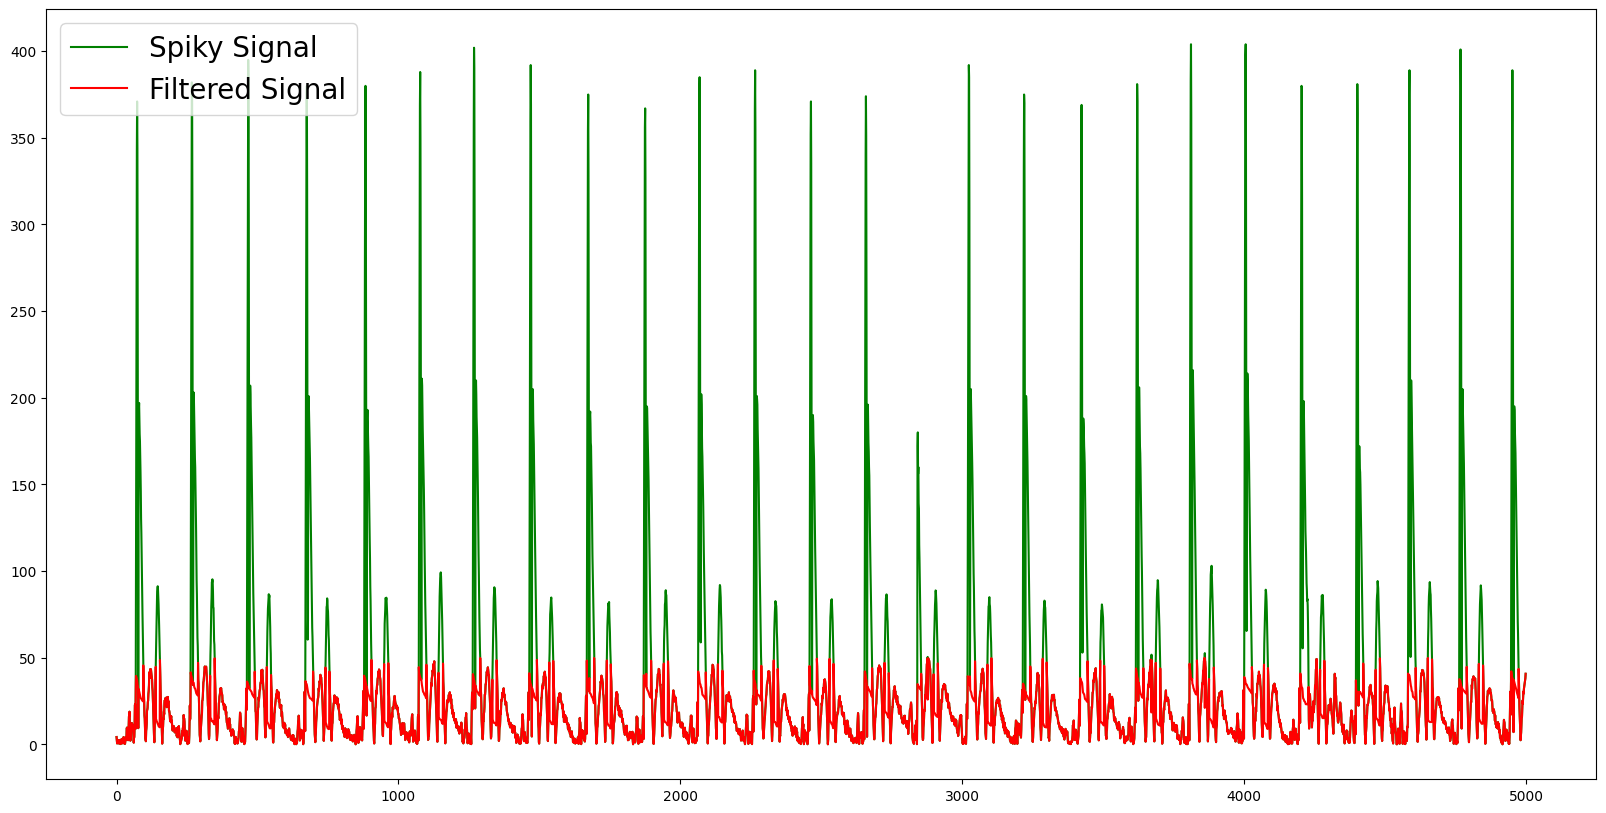

In [12]:
plt.figure(figsize = (20,10))
plt.plot(spiky, 'g', label = 'Spiky Signal')
plt.plot(filtsig, 'r', label ='Filtered Signal')
plt.legend(fontsize = 20)
plt.show()